# Train Linear SVC Model

## Motivation
**Linear Support Vector Classification (LinearSVC)** was chosen for this task for a few main reasons:

1. **Efficiency with Linear Boundaries** — It finds a very clean hyperplane to separate classes, which is extremely fast and effective for high-dimensional data (like our NLP and ISW features).
2. **Imbalance Handling** — We can use the `class_weight='balanced'` parameter to heavily penalize missed alarms (False Negatives).
3. **Scaling Required** — Unlike trees, SVC requires feature scaling (`StandardScaler`), which we implement seamlessly via a Pipeline.
4. **Interpretability** — Through the `coef_` attribute, we can see exactly which features push the prediction towards an alarm or a safe state.

In [5]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from time import time
from pathlib import Path
import warnings

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)

current_dir = Path(os.getcwd())
if "machine" in current_dir.name.lower(): 
    os.chdir(current_dir.parent) 

In [7]:
df = pd.read_csv("data/merged/merged_preprocessed.csv")

df['time'] = pd.to_datetime(df['time'], utc=True).dt.tz_convert("Europe/Kyiv")
df = df.sort_values(by=["region_id", "time"]).reset_index(drop=True)

drop_cols = ['date', 'region_city', 'year', 'month', 'day']
existing_drop_cols = [c for c in drop_cols if c in df.columns]
X = df.drop(columns=existing_drop_cols)

target = 'alarm'
y = X.pop(target)

X_features = X.drop(columns=['time'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

print(f"shape: {X_train.shape}")

shape: (658790, 112)


In [8]:
base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(class_weight='balanced', random_state=42, max_iter=2000, dual=False))
])

t0 = time()
base_model.fit(X_train, y_train)
print(f"Completed in: {time() - t0:.2f}s")

Completed in: 96.00s


In [9]:
y_pred_train = base_model.predict(X_train)
y_pred_test = base_model.predict(X_test)

y_scores_test = base_model.decision_function(X_test)

train_f1 = f1_score(y_train, y_pred_train)
test_f1 = f1_score(y_test, y_pred_test)
auprc = average_precision_score(y_test, y_scores_test)

print("-------- Overall --------")
print(f"Train F1 : {train_f1:.3f}")
print(f"Test  F1 : {test_f1:.3f}")
print(f"AUPRC    : {auprc:.3f}")

cm = confusion_matrix(y_test, y_pred_test)

-------- Overall --------
Train F1 : 0.703
Test  F1 : 0.708
AUPRC    : 0.793


## Confusion Matrix — Baseline LinearSVC

**What the metrics mean:**

* **True Negative (TN):** Model correctly predicted no alarm.
* **False Positive (FP):** Model predicted alarm but there was none.
* **False Negative (FN):** Model predicted no alarm but an alarm occurred.
* **True Positive (TP):** Model correctly predicted an alarm.

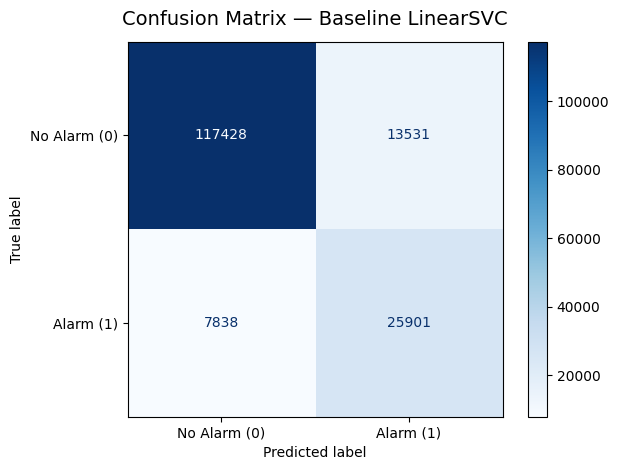

In [10]:
disp = ConfusionMatrixDisplay(cm, display_labels=["No Alarm (0)", "Alarm (1)"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix — Baseline LinearSVC", fontsize=14, pad=12)
plt.grid(False)
plt.tight_layout()
plt.show()

# Hyperparameter Tuning — GridSearchCV

## Scoring metrics chosen

* **`f1`**: Balances Precision and Recall for our imbalanced 20/80 split.
* **`average_precision`**: Best for imbalanced binary classification. Summarizes Precision-Recall trade-off.

## Parameters searched

* `C` (0.01, 0.1, 1.0): Regularization parameter. Smaller values specify stronger regularization.

In [11]:
tscv_gs = TimeSeriesSplit(n_splits=3, gap=24 * 7)

param_grid = {
    "classifier__C": [0.01, 0.1, 1.0]
}

X_gs = X.drop(columns=["time"], errors='ignore')

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(class_weight='balanced', random_state=42, max_iter=2000, dual=False))
])

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring={"f1": "f1", "average_precision": "average_precision"},
    refit="f1",
    cv=tscv_gs,
    n_jobs=1,
    verbose=2,
    return_train_score=True,
)

t0 = time()
grid_search.fit(X_gs, y)
print(f"\nGridSearchCV completed in: {time() - t0:.2f}s")

print("Best parameters:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nBest CV F1       : {grid_search.best_score_:.4f}")
print(f"Best CV AUPRC    : {grid_search.cv_results_['mean_test_average_precision'][grid_search.best_index_]:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END .................................classifier__C=0.01; total time=  16.8s
[CV] END .................................classifier__C=0.01; total time=  35.4s
[CV] END .................................classifier__C=0.01; total time= 1.1min
[CV] END ..................................classifier__C=0.1; total time=  26.9s
[CV] END ..................................classifier__C=0.1; total time=  50.5s
[CV] END ..................................classifier__C=0.1; total time=  49.5s
[CV] END ..................................classifier__C=1.0; total time=  28.5s
[CV] END ..................................classifier__C=1.0; total time=  55.2s
[CV] END ..................................classifier__C=1.0; total time=  54.2s

GridSearchCV completed in: 564.47s
Best parameters:
  classifier__C: 1.0

Best CV F1       : 0.6844
Best CV AUPRC    : 0.7868


In [12]:
cv_results = pd.DataFrame(grid_search.cv_results_)

top5 = (
    cv_results
    .sort_values("mean_test_f1", ascending=False)
    .head(5)
    [[
        "param_classifier__C",
        "mean_test_f1",
        "mean_test_average_precision",
    ]]
    .rename(columns=lambda c: c.replace("param_classifier__", "").replace("mean_test_", ""))
    .reset_index(drop=True)
)

top5

,C,f1,average_precision
0,1.00,0.684366,0.786790
1,0.10,0.684353,0.786792
2,0.01,0.684345,0.786805


In [13]:
tuned_svc_model = grid_search.best_estimator_

def evaluate_model(pipeline, X=X, y=y, n_splits: int = 3, gap: int = 24 * 7):
    fold_train_f1, fold_test_f1 = [[] for _ in range(n_splits)], [[] for _ in range(n_splits)]
    fold_auprc, fold_mcc = [[] for _ in range(n_splits)], [[] for _ in range(n_splits)]
    all_y_true, all_y_pred = [], []
    regions = sorted(X["region_id"].unique())
    t0 = time()

    for region_id in regions:
        mask_region = X["region_id"] == region_id
        unique_hours = X.loc[mask_region, "time"].sort_values().unique()
        tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)

        for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
            train_mask = X["time"].isin(unique_hours[train_idx]) & mask_region
            test_mask  = X["time"].isin(unique_hours[test_idx])  & mask_region

            X_train, X_test = X[train_mask].drop(columns=["time", "region_id"]), X[test_mask].drop(columns=["time", "region_id"])
            y_train, y_test = y[train_mask], y[test_mask]

            if len(X_test) == 0: continue

            pipeline.fit(X_train, y_train)
            y_pred_train, y_pred_test = pipeline.predict(X_train), pipeline.predict(X_test)
            
            pred_test_scores = pipeline.decision_function(X_test)

            y_train_cls, y_test_cls = (y_train > 0).astype(int), (y_test > 0).astype(int)

            fold_train_f1[fold].append(f1_score(y_train_cls, y_pred_train, zero_division=0))
            fold_test_f1[fold].append(f1_score(y_test_cls, y_pred_test, zero_division=0))
            fold_auprc[fold].append(average_precision_score(y_test_cls, pred_test_scores))
            fold_mcc[fold].append(matthews_corrcoef(y_test_cls, y_pred_test))

            all_y_true.extend(y_test_cls)
            all_y_pred.extend(y_pred_test)

    train_f1_m = [np.mean(s) for s in fold_train_f1 if s]
    test_f1_m  = [np.mean(s) for s in fold_test_f1  if s]
    auprc_m    = [np.mean(s) for s in fold_auprc if s]
    mcc_m      = [np.mean(s) for s in fold_mcc if s]

    print("\n-------- Overall --------")
    print(f"Train F1 : {np.mean(train_f1_m):.3f} ± {np.std(train_f1_m):.3f}")
    print(f"Test  F1 : {np.mean(test_f1_m):.3f} ± {np.std(test_f1_m):.3f}")
    print(f"AUPRC    : {np.mean(auprc_m):.3f} ± {np.std(auprc_m):.3f}")
    print(f"Completed in: {time() - t0:.2f}s")

    return {"train_f1": train_f1_m, "test_f1": test_f1_m, "auprc": auprc_m}, confusion_matrix(all_y_true, all_y_pred)

metrics_dict, cm_tuned = evaluate_model(tuned_svc_model, n_splits=3)


-------- Overall --------
Train F1 : 0.568 ± 0.021
Test  F1 : 0.527 ± 0.025
AUPRC    : 0.696 ± 0.023
Completed in: 244.93s


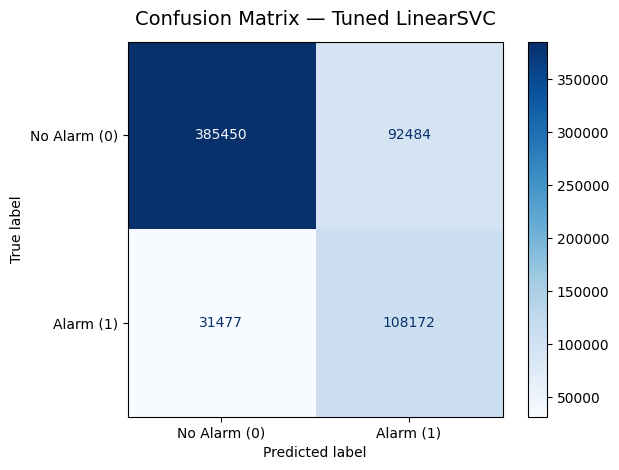

In [14]:
disp_tuned = ConfusionMatrixDisplay(
    cm_tuned,
    display_labels=["No Alarm (0)", "Alarm (1)"]
)
disp_tuned.plot(cmap="Blues", values_format='d')
plt.title(
    "Confusion Matrix — Tuned LinearSVC",
    fontsize=14, pad=12
)
plt.grid(False)
plt.tight_layout()
plt.show()

# Top 20 features and weights

Unlike Tree models that use Gini Impurity, LinearSVC provides direct **coefficients (`coef_`)**. 
Positive coefficients push the prediction towards the positive class (Alarm), while negative coefficients push it towards the negative class (No Alarm).

In [15]:
feature_names = X.drop(columns=["time", "region_id"], errors='ignore').columns.tolist()

importances = tuned_svc_model.named_steps["classifier"].coef_[0]

feat_imp = pd.DataFrame({"feature": feature_names, "weight": importances})
feat_imp["abs_weight"] = feat_imp["weight"].abs()

feat_imp = feat_imp.sort_values("abs_weight", ascending=False).reset_index(drop=True)

top20 = feat_imp.head(20)
top20

,feature,weight,abs_weight
0,nlp_нікополь,-1.104277,1.104277
1,nlp_нікополь_нікопольська,0.916917,0.916917
2,nlp_відбій,-0.623830,0.623830
3,nlp_тривоги,0.383509,0.383509
4,nlp_тривога,0.353170,0.353170
5,nlp_повітряна,-0.266279,0.266279
6,nlp_нікопольська,0.208687,0.208687
7,alarms_count_1h_ago,0.204223,0.204223
8,nlp_відбій_тривоги,-0.163499,0.163499
9,dew,0.158483,0.158483


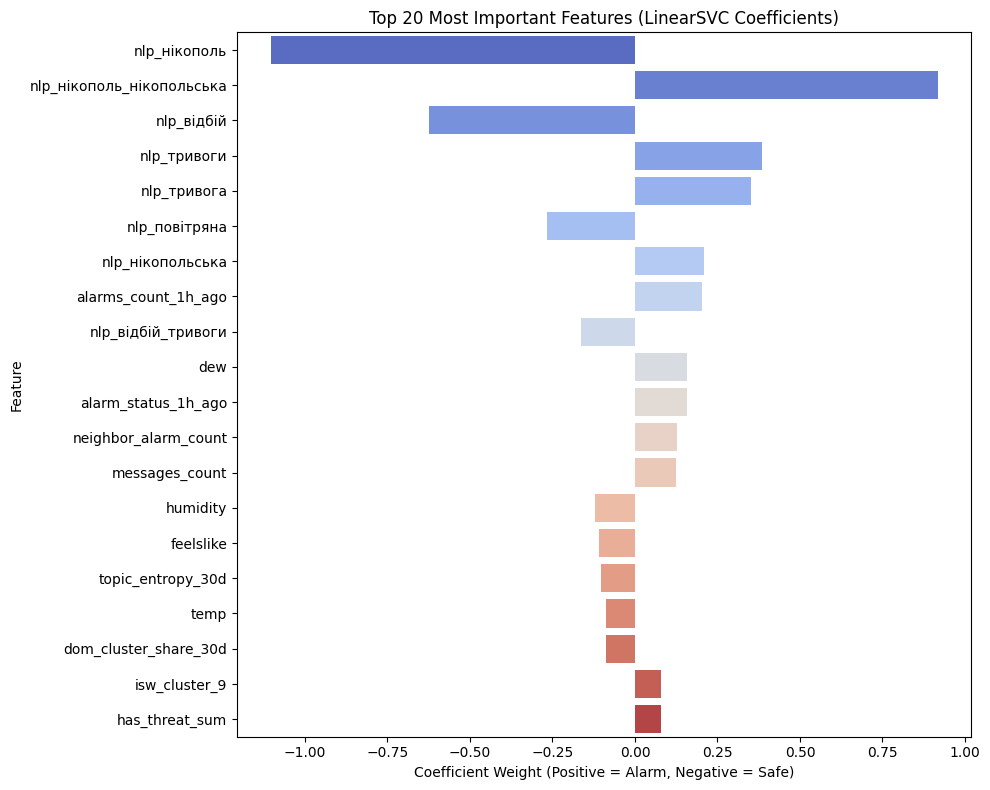

In [16]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=top20,
    x="weight",
    y="feature",
    palette="coolwarm"
)

plt.title("Top 20 Most Important Features (LinearSVC Coefficients)")
plt.xlabel("Coefficient Weight (Positive = Alarm, Negative = Safe)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [38]:
from app.db.database import Database

with Database("app/db/database.db") as db:
    new_data = db.get_merged(start_date='2026-04-08')

def check_on_new_data(pipeline, new_data=new_data):
    X_new = new_data.copy()
    target = 'alarm' 
    y_new = X_new.pop(target)
    
    X_new_features = X_new.drop(columns=["time", "region_id"], errors="ignore")
    for col in X_gs.columns:
        if col not in X_new_features.columns:
            X_new_features[col] = 0
    X_new_features = X_new_features[X_gs.columns]
    
    y_preds = pipeline.predict(X_new_features)
    score = f1_score(y_new, y_preds)
    
    ConfusionMatrixDisplay(confusion_matrix(y_new, y_preds)).plot(cmap="Blues", values_format='d')
    plt.title(f"F1 Score on New Data: {score:.4f}")
    plt.grid(False)
    plt.show()
    
    res = X_new[['region_id', 'time']].copy() if 'region_id' in X_new.columns else pd.DataFrame()
    res['alarm'] = y_new
    res['prediction'] = y_preds
    res['pred_prob_1'] = pipeline.decision_function(X_new_features) 
    
    return res

Rolling back


AssertionError: 

In [20]:
res_model = check_on_new_data(tuned_svc_model)

NameError: name 'check_on_new_data' is not defined